# **Image Filter**
 

*   Mykola Liashuha
*   Jose Gonzalez Lopez



# Introduction
In this work we will see different filters applied to an image and comment their effects after testing them a watching the main changes that happened to the new image after the transformation. In the end, we will comment our final conclusions on the notebook. 


# Imports

In [38]:
import numpy as np #Numpy for calculations
import math #For calculations
import cv2 as cv #For the images
import random #For the salt peper noise
import copy #for copy data

from matplotlib import pyplot as plt #Plots


# Auxiliar functions

In [39]:
'''
This function does the convolution operation with a specific kernel
'''
def convolve_2D(image, kernel):
    xKernShape = kernel.shape[0]
    yKernShape = kernel.shape[1]
    xImgShape = image.shape[0]
    yImgShape = image.shape[1]
    xOutput = int(((xImgShape - xKernShape)) + 1)
    yOutput = int(((yImgShape - yKernShape)) + 1)
    
    output = np.zeros((xOutput, yOutput))
    
    imagePadded = image.copy()
    
    for y in range(image.shape[1]):
    # Exit Convolution
        if y > image.shape[1] - yKernShape:
            break
        for x in range(image.shape[0]):
            # Go to next row once kernel is out of bounds
            if x > image.shape[0] - xKernShape:
                break
#             print(x, y, (kernel * imagePadded[x: x + xKernShape, y: y + yKernShape]).sum())
            output[x, y] = (kernel * imagePadded[x: x + xKernShape, y: y + yKernShape]).sum()
    
    return output


In [40]:
'''
Returns the image with salt and peper noise. IMPORTANT: This function was used 
in [1] and we just used the code just to show the effect of the filters.
'''
def add_noise(og_img):
    img=copy.deepcopy(og_img) #We do not want to change img!!!
  
    # Getting the dimensions of the image
    row = img.shape[0]
    col = img.shape[1]
      
    # Randomly pick some pixels in the
    # image for coloring them white
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300, 10000)
    for i in range(number_of_pixels):
        
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
          
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
          
        # Color that pixel to white
        img[y_coord][x_coord] = 255
          
    # Randomly pick some pixels in
    # the image for coloring them black
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300 , 10000)
    for i in range(number_of_pixels):
        
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
          
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
          
        # Color that pixel to black
        img[y_coord][x_coord] = 0
          
    return img

In [41]:
'''
Returns mean average filter of an image with a 3X3 window
'''
def mean_filter(og_img):
  img=copy.deepcopy(og_img) #We do not want to change img!!!
  img_avg=copy.deepcopy(og_img) #We store here

  heigth, width= img.shape #The shape

  for row in range (0,heigth):
    for col in range (0,width):
      sum=float(img[row][col]) #Sum of neighbours + pixel
      counter = 1 #How many do we count
      #check 8 positions
      if col-1 > 0:
          sum+=float(img[row][col-1]) #left
          if row-1 > 0:
            sum+=float(img[row-1][col-1]) #bottom left
      if col+1 < width-1:
          sum+=float(img[row][col + 1]) #right
          if row+1 <heigth-1:
            sum+=float(img[row+1][col+1]) #top right
      if row+1 < heigth-1:
          sum+=float(img[row+1][col]) #top
          if col-1 > 0:
            sum+=float(img[row+1][col-1]) #top left
      if row-1 > 0:
          sum+=float(img[row - 1][col]) #bottom
          if col+1 < width-1:
            sum+=float(img[row-1][col+1]) #bottom right
      #Do average
      avg = sum / 9
      #Save
      img_avg[row][col] = avg

  return img_avg

In [42]:
'''
Create a gaussian kernel
'''
def get_gaussian_kernel(filter_size, sigma=1):

    gaussian_filter = np.zeros((filter_size, filter_size), np.float32)

    k = filter_size // 2
    p = k

    for x in range(-k, k+1):
        for y in range(-k, k+1):
            x1 = 2*np.pi*(sigma**2)
            x2 = np.exp(-(x**2 + y**2)/(2* sigma**2))
            gaussian_filter[x+k, y+k] = (1/x1)*x2

    s = np.sum(gaussian_filter)
    if s != 1.:
        gaussian_filter = gaussian_filter / s
        
    return gaussian_filter

# Original image
Let's first see the original image to which we are going to apply the filters.

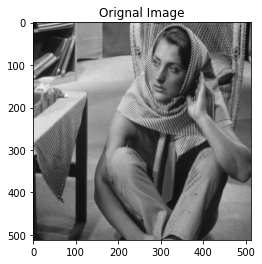

In [43]:
img = cv.imread('barbara.jpg') #Reading
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY) #Convert to gray
plt.imshow(gray,'gray') #And plot
plt.title("Orignal Image")

plt.show()

# Gradient Filter
Gradient filters are the ones that will detect the directions of the points that change in intensity quicker. These points will be the edges. To compute them, we will use the derivatives in the two dimensions of the image to detect those edges in the direction of those variables (horizontal edges and vertical edges). The use of getting these gradient images will help us to get the Sobel filter later.

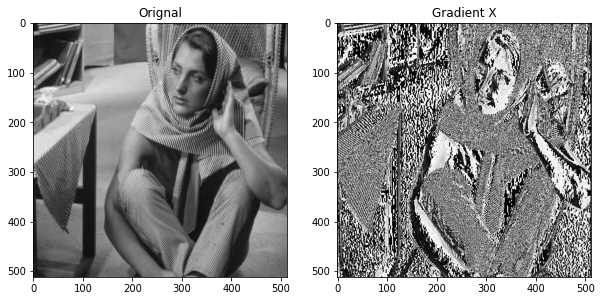

In [44]:
img_gradient_x = cv.Sobel(gray,cv.CV_64F,1,0) #The sobel library from cv2 will get us the gradients in the x direction

# And this is to plot the filtered image and the original
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(1, 2, 2)
plt.imshow(img_gradient_x.astype('uint8'),cmap = 'gray')
plt.title("Gradient X")

plt.show()

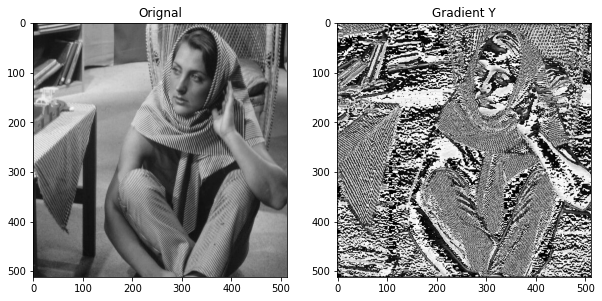

In [45]:
img_gradient_y = cv.Sobel(gray,cv.CV_64F,0,1) #The sobel library from cv2 will get us the gradients in the y direction

# And this is to plot the filtered image and the original
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(1, 2, 2)
plt.imshow(img_gradient_y.astype('uint8'),cmap = 'gray')
plt.title("Gradient Y")

plt.show()

# Sobel Filter
Using both gradients will give us the Sobel filter and with this operation, the edges of the original image will be highlited. Computing the magnitude of the gradients will also help us to identify the edges more smoothly and it will also reasure us that the gradient filters were computed correctly. [2]

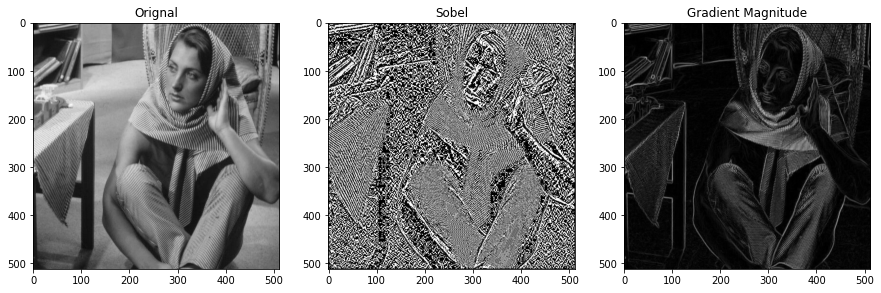

In [46]:
#Sobel
sobel=cv.Sobel(gray,cv.CV_64F,1,1)

#Using the gradient magnitude
gradient_magnitude=np.sqrt(img_gradient_x**2+img_gradient_y**2)
gradient_magnitude *= 255.0 / gradient_magnitude.max()
orientation = np.arctan2(img_gradient_y, img_gradient_y) * (180 / np.pi) % 180

#Plot results
fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(1, 3, 2)
plt.imshow(sobel.astype('uint8'),cmap="gray")
plt.title("Sobel")

fig.add_subplot(1, 3, 3)
plt.imshow(gradient_magnitude.astype('uint8'),cmap="gray")
plt.title("Gradient Magnitude")

plt.show()

Thanks to the Gradient magnitude, the edges on this image are well identified while on Sobel seems to be a mess of connected edges everywhere. If we look closely to the original image, the clothes have a lot of lines in multiple directions and Sobel is highliting all of them. The Gradient magnitude is actually helping us to filter those edges that do not give much information and keeping the most important ones. 

# Average Filter
The Average filter is an operation whose main objective is to smooth the image by taking the mean of the neighbour pixels and compute a new value for each position of the photograph. It is considered a FIR low pass filter. [3] In this case we have used a 3X3 sliding window and and 7X7 window to see the difference between the operations with the CV2 library and then we will compute the operation with our own filter.

## CV2 Implementation

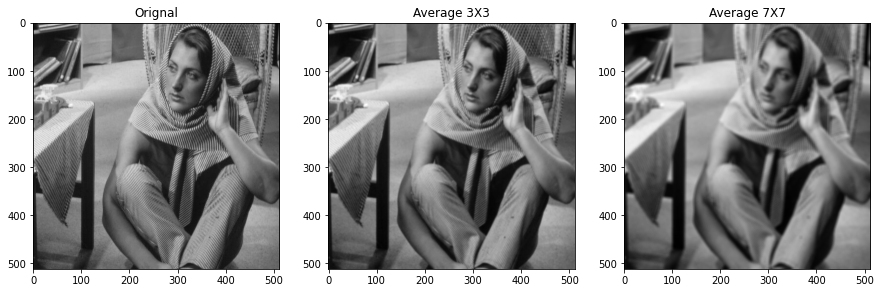

In [47]:
img_avg_33 = cv.blur(src=gray,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=gray,ksize=(7,7)) #Doing average 7x7 kernel

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(1, 3, 2)
plt.imshow(img_avg_33,'gray')
plt.title("Average 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_avg_77,'gray')
plt.title("Average 7X7")

plt.show()

As we can see, in this case the 7X7 window had a much greater impact than the 3X3. In this type of cases, this filter seems to be useless to actually help us get a better image or retrieve information like Sobel or the Gradients. What what if the image was not perfectly computed and had some misinformation or noise? That is where this filter can actually be very useful. Let's apply some noise over the original image and then apply the same operations to see the full potential of these filters. [1]

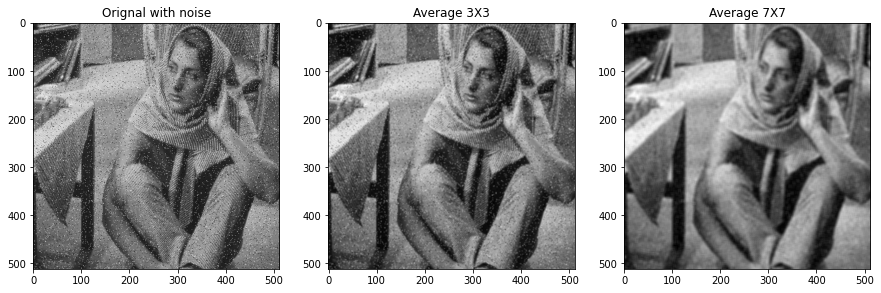

In [48]:
img_noise=add_noise(gray)
img_avg_33 = cv.blur(src=img_noise,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=img_noise,ksize=(7,7)) #Doing average 9x9 kernel

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(img_noise,'gray')
plt.title("Orignal with noise")

fig.add_subplot(1, 3, 2)
plt.imshow(img_avg_33,'gray')
plt.title("Average 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_avg_77,'gray')
plt.title("Average 7X7")

plt.show()

As we can see, the noise was almost removed in the 3X3 window and on the 7X7 format, the process is even smoother.

## Our implementation
In this section we will just compare our filter implementation vs the CV library one.


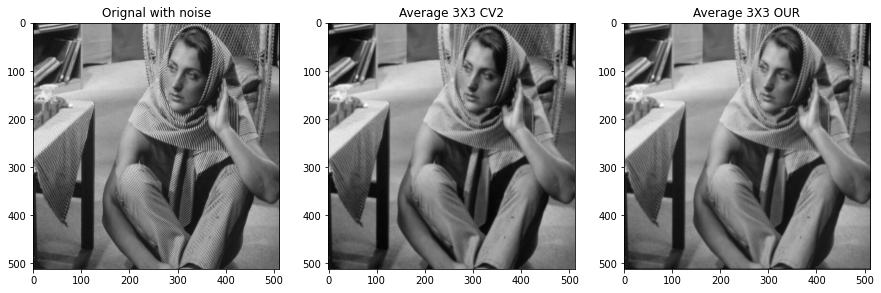

In [49]:
img_avg_our=mean_filter(gray) #Our implementation
img_avg_33 = cv.blur(src=gray,ksize=(3,3)) #CV

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(gray,cmap='gray')
plt.title("Orignal with noise")

fig.add_subplot(1, 3, 2)
plt.imshow(img_avg_33,cmap='gray')
plt.title("Average 3X3 CV2")

fig.add_subplot(1, 3, 3)
plt.imshow(X=img_avg_our.astype('uint8'),cmap="gray")
plt.title("Average 3X3 OUR")

plt.show()


Seems we have achieved a very similar results. The only difference is that we have a fixed window kernel and CV has a dynamic one.

# Gaussian Filter
The Gaussian Filter uses the Gaussian function as the impulse response. It is considered an ideal filter in the time domain and its main application is similar to the averaging filter. [4] We will have the same window size as the Average filter study to see the differences between both of them and our own implementation

## CV2 Implementation

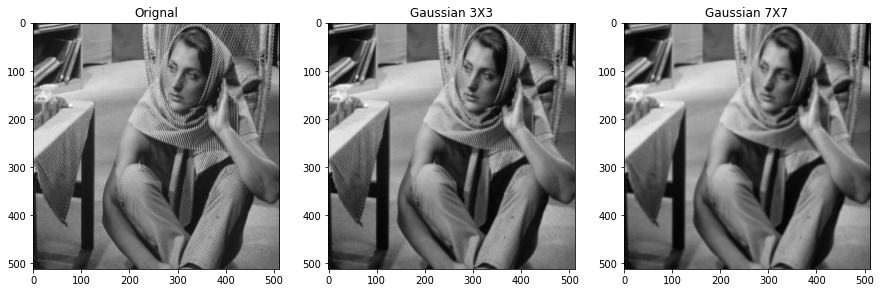

In [50]:
img_gaussian_blur_33 = cv.GaussianBlur(gray,(3,3),sigmaX=0)
img_gaussian_blur_77 = cv.GaussianBlur(gray,(7,7),sigmaX=0)

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(1, 3, 2)
plt.imshow(img_gaussian_blur_33,'gray')
plt.title("Gaussian 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_gaussian_blur_77,'gray')
plt.title("Gaussian 7X7")

plt.show()

The effect seems to be quite similar with the average filter. Let's add noise to the formula.

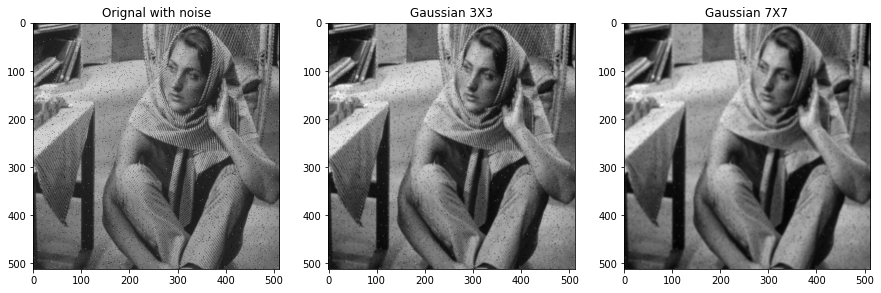

In [51]:
img_noise=add_noise(gray)
img_gaussian_blur_33 = cv.GaussianBlur(img_noise,(3,3),sigmaX=0) #Gaussian 3X3
img_gaussian_blur_77 = cv.GaussianBlur(img_noise,(7,7),sigmaX=0) #Gaussian 7X7

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(1, 3, 1)
plt.imshow(img_noise,'gray')
plt.title("Orignal with noise")

fig.add_subplot(1, 3, 2)
plt.imshow(img_gaussian_blur_33,'gray')
plt.title("Gaussian 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_gaussian_blur_77,'gray')
plt.title("Gaussian 7X7")

plt.show()

We can see here all of them into on plot

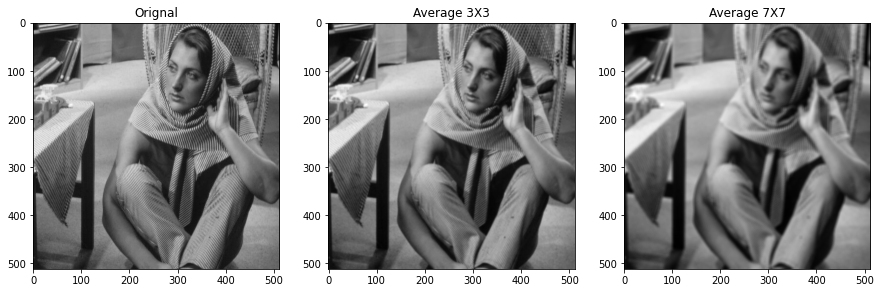

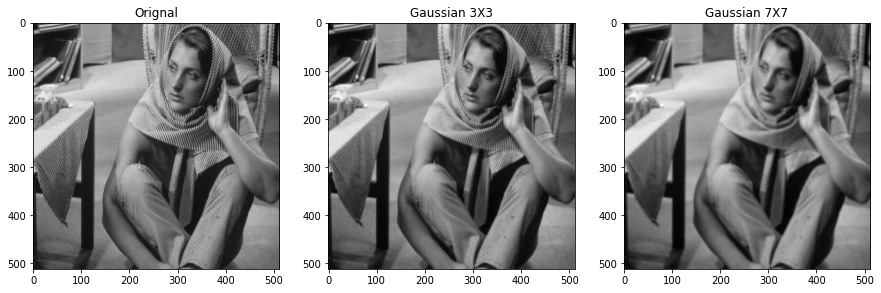

In [52]:
img_avg_33 = cv.blur(src=gray,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=gray,ksize=(7,7)) #Doing average 7x7 kernel

img_gaussian_blur_33 = cv.GaussianBlur(gray,(3,3),sigmaX=0) #Gaussian 3X3
img_gaussian_blur_77 = cv.GaussianBlur(gray,(7,7),sigmaX=0) #Gaussian 7X7

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 3, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(2, 3, 2)
plt.imshow(img_avg_33,'gray')
plt.title("Average 3X3")

fig.add_subplot(2, 3, 3)
plt.imshow(img_avg_77,'gray')
plt.title("Average 7X7")

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 3, 4)
plt.imshow(gray, 'gray')
plt.title("Orignal")

fig.add_subplot(2, 3, 5)
plt.imshow(img_gaussian_blur_33,'gray')
plt.title("Gaussian 3X3")

fig.add_subplot(2, 3, 6)
plt.imshow(img_gaussian_blur_77,'gray')
plt.title("Gaussian 7X7")

plt.show()

And here we can compare the two filters with the noisy image.

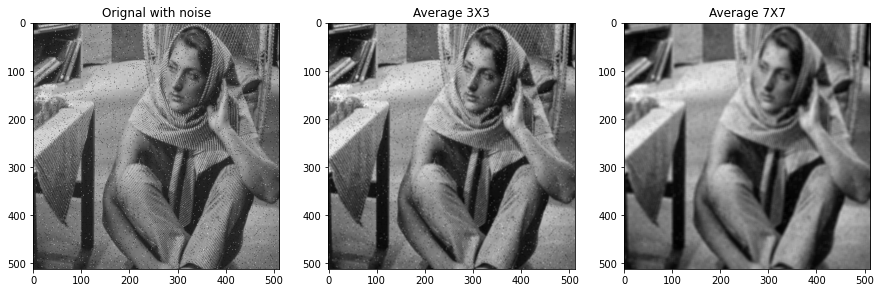

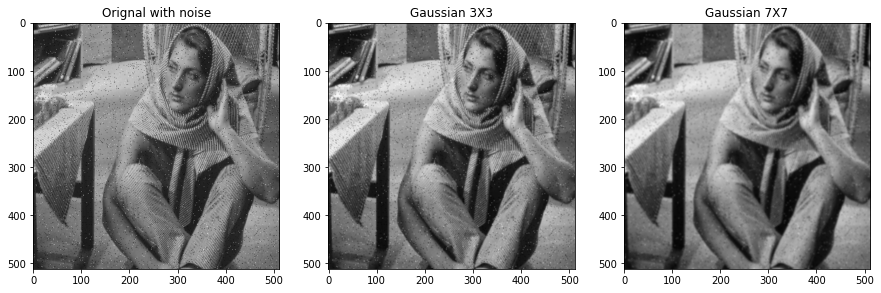

In [53]:
img_noise=add_noise(gray)

img_avg_33 = cv.blur(src=img_noise,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=img_noise,ksize=(7,7)) #Doing average 9x9 kernel

img_gaussian_blur_33 = cv.GaussianBlur(img_noise,(3,3),sigmaX=0) #Gaussian 3X3
img_gaussian_blur_77 = cv.GaussianBlur(img_noise,(7,7),sigmaX=0) #Gaussian 7X7

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 3, 1)
plt.imshow(img_noise,'gray')
plt.title("Orignal with noise")

fig.add_subplot(2, 3, 2)
plt.imshow(img_avg_33,'gray')
plt.title("Average 3X3")

fig.add_subplot(2, 3, 3)
plt.imshow(img_avg_77,'gray')
plt.title("Average 7X7")

plt.show()

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 3, 4)
plt.imshow(img_noise,'gray')
plt.title("Orignal with noise")

fig.add_subplot(2, 3, 5)
plt.imshow(img_gaussian_blur_33,'gray')
plt.title("Gaussian 3X3")

fig.add_subplot(2, 3, 6)
plt.imshow(img_gaussian_blur_77,'gray')
plt.title("Gaussian 7X7")

plt.show()

The Average filter removes noise but makes the image less clearer than the Gaussian filter, that priotizes que quality of the image even if the noise was not removed completeley.

## Our implementation
We will have the same experiment as the Average filter.

(512, 512) (510, 510) (506, 506)


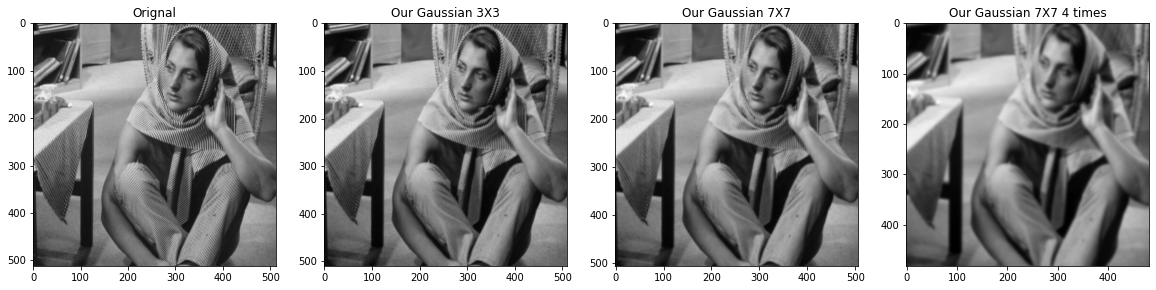

In [54]:

img_gaussian_blur_33 = convolve_2D(gray, get_gaussian_kernel(3)).astype('uint8')
img_gaussian_blur_77 = convolve_2D(gray, get_gaussian_kernel(7)).astype('uint8')

img_gaussian_blur_77_4_times = img_gaussian_blur_77
for i in range(4):
    img_gaussian_blur_77_4_times = convolve_2D(img_gaussian_blur_77_4_times, get_gaussian_kernel(7)).astype('uint8')

print(gray.shape, img_gaussian_blur_33.shape, img_gaussian_blur_77.shape)

fig = plt.figure(figsize=(20, 20))
fig.add_subplot(1, 4, 1)
plt.imshow(gray, cmap='gray')
plt.title("Orignal")

fig.add_subplot(1, 4, 2)
plt.imshow(img_gaussian_blur_33, cmap='gray')
plt.title("Our Gaussian 3X3")

fig.add_subplot(1, 4, 3)
plt.imshow(img_gaussian_blur_77, cmap='gray')
plt.title("Our Gaussian 7X7")

fig.add_subplot(1, 4, 4)
plt.imshow(img_gaussian_blur_77_4_times, cmap='gray')
plt.title("Our Gaussian 7X7 4 times")


plt.show()

Here we have just added the 4 times operatin to verify that the filter works. And now we can compre results one last time



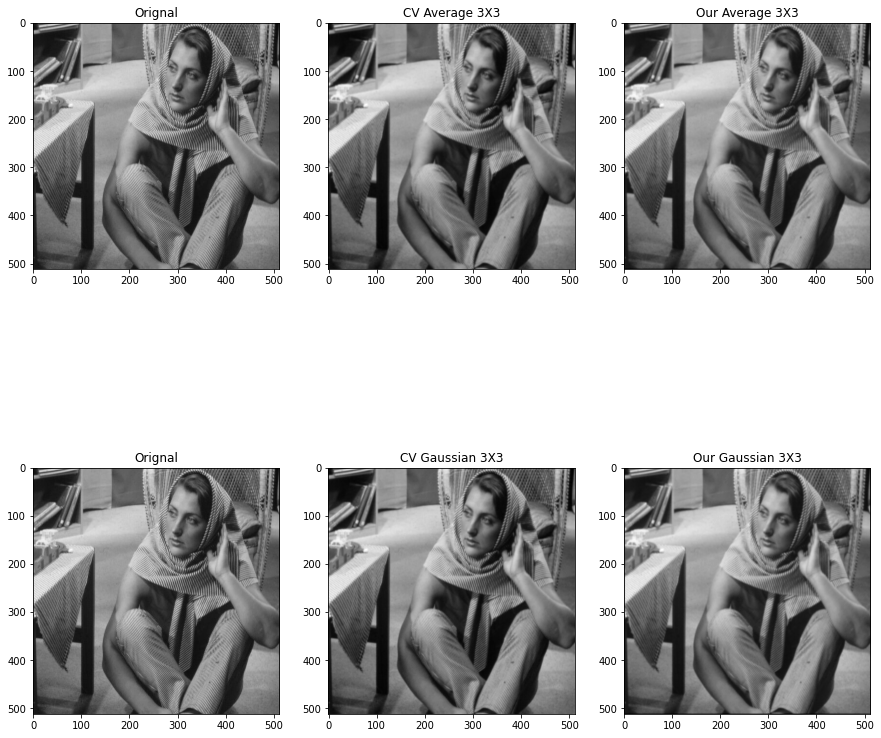

In [55]:
img_avg_33 = cv.blur(src=gray,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_33_our=mean_filter(gray) #Our implementation
img_gaussian_blur_33 = cv.GaussianBlur(gray,(3,3),sigmaX=0) #Gaussian 3X3
img_gaussian_blur_33_our = convolve_2D(gray, get_gaussian_kernel(3)).astype('uint8')

fig = plt.figure(figsize=(15, 15))
fig.add_subplot(2, 3, 1)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(2, 3, 2)
plt.imshow(img_avg_33,'gray')
plt.title("CV Average 3X3")

fig.add_subplot(2, 3, 3)
plt.imshow(img_avg_33_our,'gray')
plt.title("Our Average 3X3")

fig.add_subplot(2, 3, 4)
plt.imshow(gray,'gray')
plt.title("Orignal")

fig.add_subplot(2, 3, 5)
plt.imshow(img_gaussian_blur_33,'gray')
plt.title("CV Gaussian 3X3")

fig.add_subplot(2, 3, 6)
plt.imshow(img_avg_33_our,'gray')
plt.title("Our Gaussian 3X3")

plt.show()

# Conclusions
In this notebook, we have reviewed some interesting filters for images and try to see the main characteristics of each of them and their effects. The Gradient and Sobel filters focus more on edge detection while the Average and Gaussian filters deal with noisy data and try to smooth the image applying different, but effective techniques that have diverse results on the data. We have also tried to implement these filters by our own hands but in general this tools are already programmed with far more parameters and customization.

# References
[1] [Salt and peper code](https://www.geeksforgeeks.org/add-a-salt-and-pepper-noise-to-an-image-with-python/)

[2] [Gradients and Sobel Filter](https://en.wikipedia.org/wiki/Sobel_operator)

[3] [Average Filter](https://www.gaussianwaves.com/2010/11/moving-average-filter-ma-filter-2//)

[4] [Gaussian Filter](https://everything.explained.today/Gaussian_filter/)